# Cat_Boost ALgorithm

#  CatBoost is a state-of-the-art open-source gradient boosting on decision trees library.


---


 It is developed by Yandex researchers and engineers, and is used for search,
recommendation systems, personal assistant, self-driving cars, weather prediction and many other tasks at Yandex and in other companies.

 It is in Python and it is designed to be integrated in data science pipelines.
  It provides state-of-the-art results and it is powerful in handling categorical features.
  Do we need to encode categorical features before training the model? No, CatBoost does not require it.
 It is efficient. It provides a fast and scalable multi-threaded implementation of the algorithm.
 It provides powerful visualization tools to understand the model.

In [ ]:
# import libraries
!pip install catboost
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.8 MB/s eta 0:00:00


In [ ]:
df = sns.load_dataset('titanic')

In [ ]:
from sklearn.impute import KNNImputer
imputer = KNNImputer(n_neighbors=5)
df['age'] = imputer.fit_transform(df[['age']])
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])
df['embark_town'] = df['embark_town'].fillna(df['embark_town'].mode()[0])
df.drop('deck' , axis = 1, inplace = True)


In [ ]:

df = df.drop(['alive'], axis=1)
# convert each category/object column to category
categorical_cols = df.select_dtypes(include=['object', 'category']).columns
# add this as a new column in the dataframe
df[categorical_cols] = df[categorical_cols].astype('category')

In [ ]:
# split data into X and y
X = df.drop('survived', axis=1)
y = df['survived']

# split data into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# CatBoostClassifier


Learning rate set to 0.008672
0:	learn: 0.6868010	total: 67ms	remaining: 1m 6s
1:	learn: 0.6835501	total: 69.5ms	remaining: 34.7s
2:	learn: 0.6777264	total: 79.7ms	remaining: 26.5s
3:	learn: 0.6717020	total: 89.9ms	remaining: 22.4s
4:	learn: 0.6659274	total: 107ms	remaining: 21.2s
5:	learn: 0.6607063	total: 117ms	remaining: 19.4s
6:	learn: 0.6553588	total: 130ms	remaining: 18.4s
7:	learn: 0.6499141	total: 147ms	remaining: 18.2s
8:	learn: 0.6450543	total: 151ms	remaining: 16.6s
9:	learn: 0.6396165	total: 155ms	remaining: 15.4s
10:	learn: 0.6342532	total: 161ms	remaining: 14.5s
11:	learn: 0.6296966	total: 216ms	remaining: 17.8s
12:	learn: 0.6252078	total: 223ms	remaining: 17s
13:	learn: 0.6208193	total: 230ms	remaining: 16.2s
14:	learn: 0.6158549	total: 248ms	remaining: 16.3s
15:	learn: 0.6116021	total: 264ms	remaining: 16.2s
16:	learn: 0.6092687	total: 269ms	remaining: 15.5s
17:	learn: 0.6049553	total: 279ms	remaining: 15.2s
18:	learn: 0.6008440	total: 287ms	remaining: 14.8s
19:	learn: 

Text(0.5, 1.0, 'Confusion Matrix')

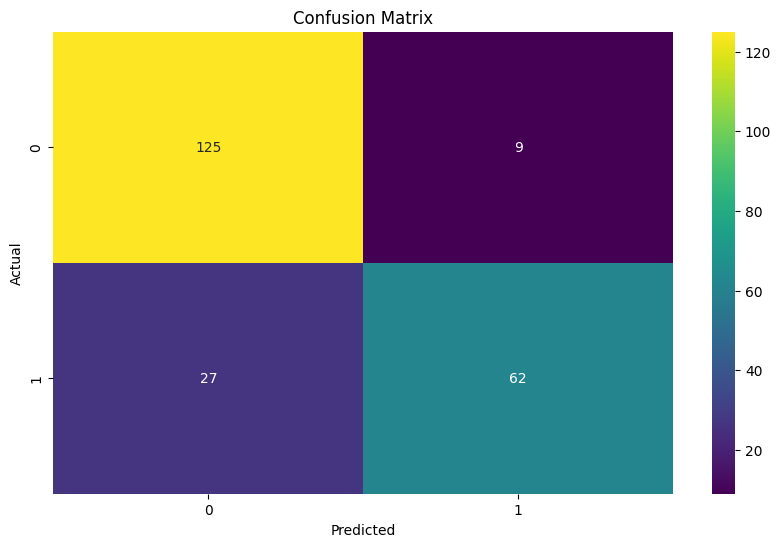

In [ ]:
%%time
# run the catboost classifier
model = CatBoostClassifier()

# train the model
model.fit(X_train, y_train, cat_features=categorical_cols.tolist())

# predictions
y_pred = model.predict(X_test)

# evaluate the model
print(f'Accuracy Score: {accuracy_score(y_test, y_pred)}')
print(f'Confusion Matrix: \n {confusion_matrix(y_test, y_pred)}')
print(f'Classification Report: \n {classification_report(y_test, y_pred)}')

# plot confusion matrix
plt.figure(figsize=(10, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='viridis')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')


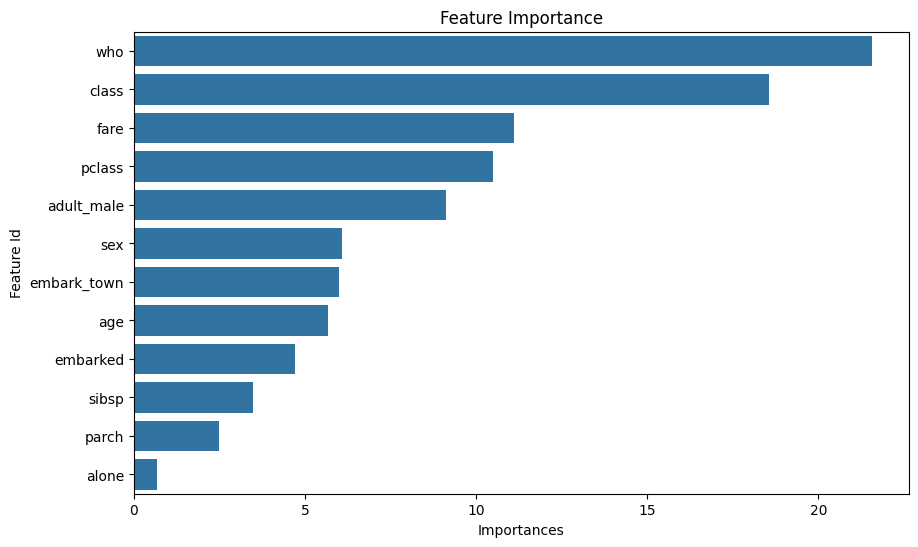

In [ ]:
# feature importance
feature_importance = model.get_feature_importance(prettified=True)
plt.figure(figsize=(10, 6))
sns.barplot(x='Importances', y='Feature Id', data=feature_importance)
plt.title('Feature Importance')
plt.show()